# Track Metrics Plots
Regenerates all plots from JSON data files saved alongside the PNGs.
Edit the path and style variables below, then re-run all cells.

In [1]:
%matplotlib inline
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

# ── Path to the directory containing the JSON files ───────────────────────────
PLOT_DIR = Path("/data/alice/bkuipers/low_pt_gnn_pipeline/data_300_mixed/visuals/track_metrics/testset_helix_minlen7")

# ── Figure style ──────────────────────────────────────────────────────────────
FIGSIZE      = (7, 5)       # (width, height) in inches
FONT_AXIS    = 18           # axis label font size
FONT_TICK    = 14           # tick label font size
FONT_LEGEND  = 14           # legend font size
FONT_TITLE   = 18           # title font size
CAPSIZE      = 3
MARKERSIZE   = 3 
GRID_ALPHA   = 0.3
DPI          = 150          # set to None to skip saving; otherwise saves next to JSON
AUTO_XLIM    = True         # True: fit x-axis to actual data range; False: use stored xlim

# ── Segment matching specific ─────────────────────────────────────────────────
MIN_BIN_FRACTION = 0.03     # suppress bins with < this fraction of peak-bin count (segment matching plots only)

print(f"Looking for JSON files in: {PLOT_DIR}")
json_files = sorted(PLOT_DIR.glob("*.json"))
print(f"Found {len(json_files)} file(s):")
for f in json_files:
    print(f"  {f.name}")

Looking for JSON files in: /data/alice/bkuipers/low_pt_gnn_pipeline/data_300_mixed/visuals/track_metrics/testset_helix_minlen7
Found 8 file(s):
  clone_rate_vs_eta_testset_helix_minlen7.json
  clone_rate_vs_pt_testset_helix_minlen7.json
  completeness_vs_eta_testset_helix_minlen7.json
  completeness_vs_pt_testset_helix_minlen7.json
  efficiency_vs_eta_testset_helix_minlen7.json
  efficiency_vs_pt_testset_helix_minlen7.json
  purity_vs_eta_testset_helix_minlen7.json
  purity_vs_pt_testset_helix_minlen7.json


In [2]:
import re

def none_to_nan(lst):
    """Convert a list with None entries back to a numpy array with np.nan."""
    return np.array([np.nan if v is None else v for v in lst], dtype=float)


def _data_xlim(data: dict, pad_fraction=0.08) -> list:
    """Compute xlim from the actual x ± xerr range across all series."""
    lo, hi = np.inf, -np.inf
    for s in data.get("series", []):
        x    = none_to_nan(s["x"])
        xerr = none_to_nan(s["xerr"])
        valid = ~np.isnan(x) & ~np.isnan(s["y"] if isinstance(s["y"], np.ndarray)
                                          else none_to_nan(s["y"]))
        if not np.any(valid):
            continue
        lo = min(lo, float(np.nanmin(x[valid] - xerr[valid])))
        hi = max(hi, float(np.nanmax(x[valid] + xerr[valid])))
    if not np.isfinite(lo) or not np.isfinite(hi):
        return None
    pad = max((hi - lo) * pad_fraction, 0.02)
    return [lo - pad, hi + pad]


def _apply_min_bin_fraction(s: dict, min_bin_fraction: float) -> dict:
    """Return a copy of series s with sparse bins masked to NaN."""
    if "n" not in s:
        return s
    n = none_to_nan(s["n"])
    peak = np.nanmax(n) if np.any(~np.isnan(n)) else 1
    sparse = n < min_bin_fraction * peak
    y      = none_to_nan(s["y"]).copy()
    ylo    = none_to_nan(s["yerr_lo"]).copy()
    yhi    = none_to_nan(s["yerr_hi"]).copy()
    y[sparse] = np.nan
    ylo[sparse] = np.nan
    yhi[sparse] = np.nan
    return {**s, "y": y, "yerr_lo": ylo, "yerr_hi": yhi}


def add_pt_minor_grid(ax):
    """Add faint grid lines every 0.05 GeV on the pT (x) axis (no extra tick labels)."""
    ax.xaxis.set_minor_locator(MultipleLocator(0.05))
    ax.grid(True, which="minor", axis="x", alpha=GRID_ALPHA * 0.5)


def render_plot(data: dict, figsize=FIGSIZE, save_path=None,
                min_bin_fraction=None, ylabel_fontsize=None, ylabel=None) -> plt.Figure:
    """Render one plot from its JSON data dict.

    Returns the Figure so the notebook can display or further tweak it.
    ylabel_fontsize overrides FONT_AXIS for the y-axis label only.
    ylabel overrides the label text stored in the JSON.
    """
    fig, ax = plt.subplots(figsize=figsize)

    for s in data.get("series", []):
        if min_bin_fraction is not None:
            s = _apply_min_bin_fraction(s, min_bin_fraction)
        x       = none_to_nan(s["x"])
        xerr    = none_to_nan(s["xerr"])
        y       = none_to_nan(s["y"])
        yerr_lo = none_to_nan(s["yerr_lo"])
        yerr_hi = none_to_nan(s["yerr_hi"])
        label   = re.sub(r"\s*\(.*?\)\s*$", "", s.get("label", ""))

        ax.errorbar(
            x, y,
            xerr=xerr, yerr=[yerr_lo, yerr_hi],
            fmt=s.get("marker", "o"),
            color=s.get("color", None),
            label=label,
            capsize=CAPSIZE, capthick=1.5, markersize=MARKERSIZE,
        )

    ax.set_xlabel(data.get("xlabel", ""), fontsize=FONT_AXIS)
    ax.set_ylabel(ylabel if ylabel is not None else data.get("ylabel", ""),
                  fontsize=ylabel_fontsize if ylabel_fontsize is not None else FONT_AXIS)
    ax.tick_params(axis="both", labelsize=FONT_TICK)
    ax.grid(True, alpha=GRID_ALPHA)
    ax.legend(fontsize=FONT_LEGEND)

    if "p_T" in data.get("xlabel", ""):
        add_pt_minor_grid(ax)

    if AUTO_XLIM:
        xlim = _data_xlim(data)
        if xlim is not None:
            ax.set_xlim(xlim)
    elif "xlim" in data and data["xlim"] is not None:
        ax.set_xlim(data["xlim"])

    if "ylim" in data and data["ylim"] is not None:
        ax.set_ylim(data["ylim"])

    plt.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, bbox_inches="tight")

    return fig


def load_and_render(json_path: Path, save_suffix="_replot",
                    min_bin_fraction=None, ylabel_fontsize=None, ylabel=None) -> plt.Figure:
    """Load JSON and render. Saves a PDF next to the JSON."""
    with open(json_path) as f:
        data = json.load(f)
    if "title" in data:
        print(data["title"])
    save_path = json_path.with_name(json_path.stem + save_suffix + ".pdf")
    return render_plot(data, save_path=save_path, min_bin_fraction=min_bin_fraction,
                       ylabel_fontsize=ylabel_fontsize, ylabel=ylabel)


print("Helper functions defined.")

Helper functions defined.


## Track Efficiency

efficiency_vs_eta_testset_helix_minlen7
Track Efficiency vs ETA (Overall: 0.845)


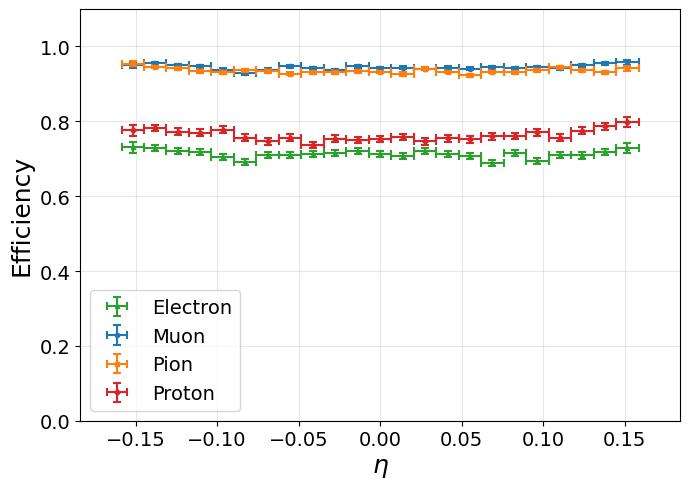

efficiency_vs_pt_testset_helix_minlen7
Track Efficiency vs PT (Overall: 0.845)


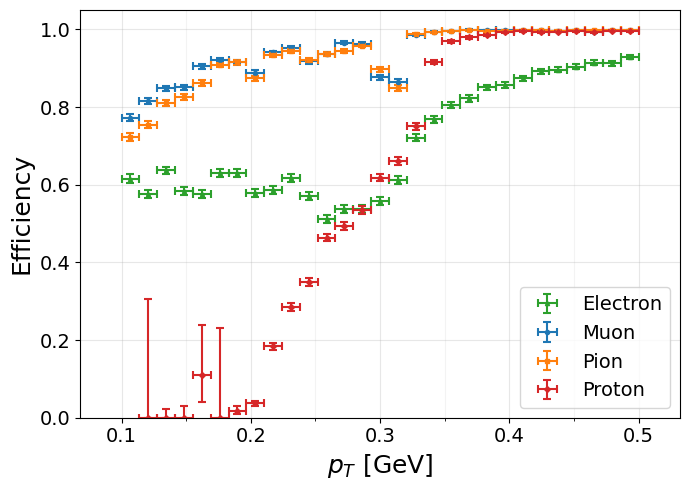

In [3]:
for p in sorted(PLOT_DIR.glob("efficiency_vs_*.json")):
    print(p.stem)
    fig = load_and_render(p)
    plt.show()


## Clone Rate

clone_rate_vs_eta_testset_helix_minlen7
Clone Rate vs ETA (Overall: 0.000)


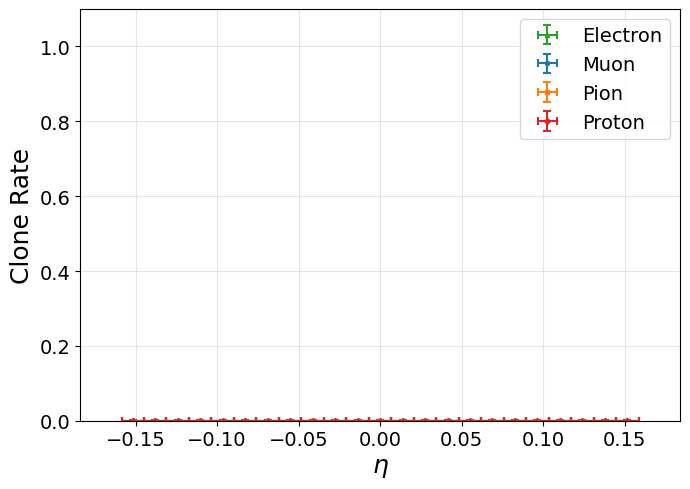

clone_rate_vs_pt_testset_helix_minlen7
Clone Rate vs PT (Overall: 0.000)


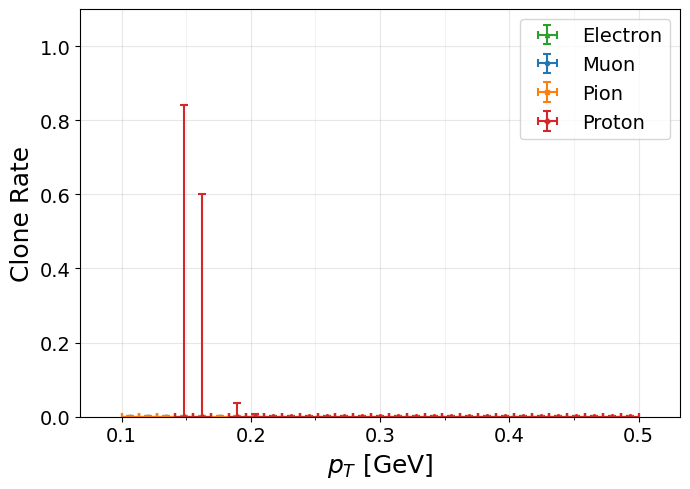

In [4]:
for p in sorted(PLOT_DIR.glob("clone_rate_vs_*.json")):
    print(p.stem)
    fig = load_and_render(p)
    plt.show()


## Track Purity

purity_vs_eta_testset_helix_minlen7
Track Purity vs ETA (Overall: 0.821)


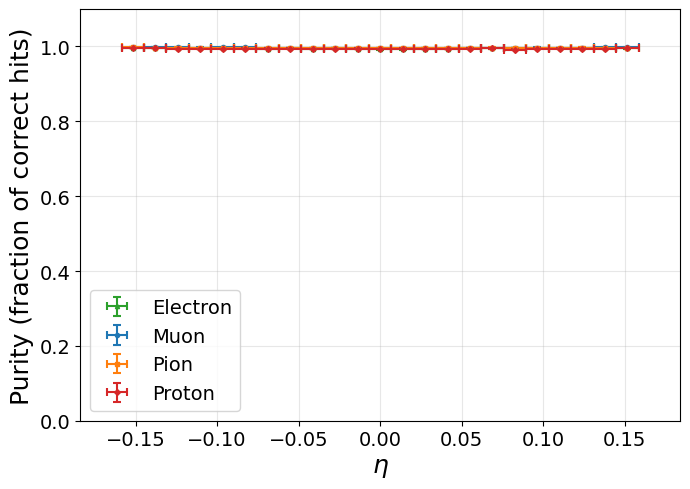

purity_vs_pt_testset_helix_minlen7
Track Purity vs PT (Overall: 0.821)


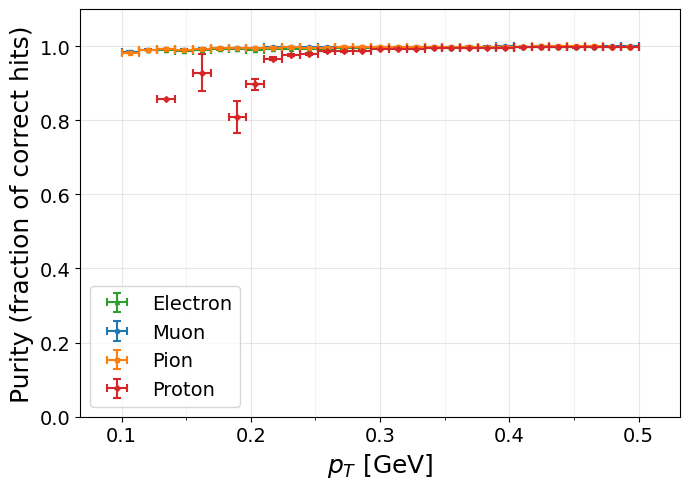

In [5]:
for p in sorted(PLOT_DIR.glob("purity_vs_*.json")):
    print(p.stem)
    fig = load_and_render(p)
    plt.show()


## Track Completeness

completeness_vs_eta_testset_helix_minlen7
Track Completeness vs ETA (Overall: 0.752)


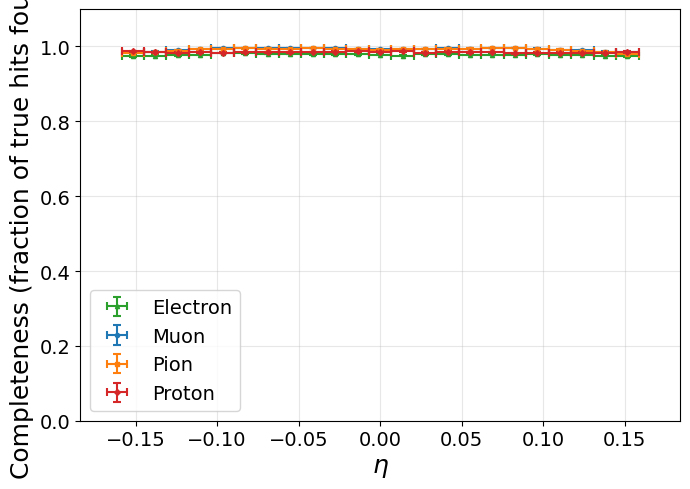

completeness_vs_pt_testset_helix_minlen7
Track Completeness vs PT (Overall: 0.752)


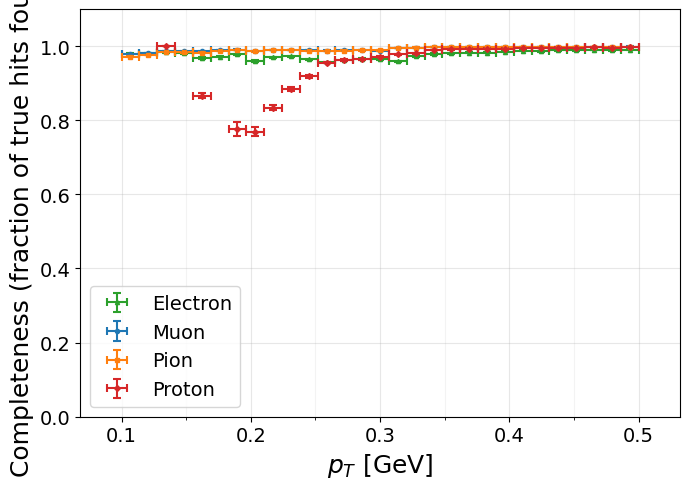

In [6]:
for p in sorted(PLOT_DIR.glob("completeness_vs_*.json")):
    print(p.stem)
    fig = load_and_render(p)
    plt.show()


## Segment Matching Efficiency

In [7]:
for p in sorted(PLOT_DIR.glob("matching_efficiency_*.json")):
    print(p.stem)
    fig = load_and_render(p, min_bin_fraction=MIN_BIN_FRACTION)
    plt.show()


## Segment-level Plots (efficiency / purity / completeness)

In [8]:
for p in sorted(PLOT_DIR.glob("segment_*.json")):
    print(p.stem)
    fig = load_and_render(p)
    plt.show()


## Any remaining JSON files

In [9]:
known_patterns = [
    "efficiency_vs_*.json",
    "clone_rate_vs_*.json",
    "purity_vs_*.json",
    "completeness_vs_*.json",
    "matching_efficiency_*.json",
    "segment_*.json",
]
already_shown = set()
for pat in known_patterns:
    already_shown.update(PLOT_DIR.glob(pat))

remaining = [p for p in sorted(PLOT_DIR.glob("*.json")) if p not in already_shown]
if remaining:
    for p in remaining:
        print(p.stem)
        fig = load_and_render(p)
        plt.show()
else:
    print("All JSON files covered by the sections above.")

All JSON files covered by the sections above.


## GT Segments per Particle vs pT

In [10]:
# import torch
# import pandas as pd

# FEATURE_STORE_DIR = Path("/data/alice/bkuipers/low_pt_gnn_pipeline/data_300_mixed/feature_store/testset")
# GT_SEG_OUT = PLOT_DIR / "gt_segments_per_particle_vs_pt.pdf"

# PDG_MAP     = {11: "Electron", 13: "Muon", 211: "Pion", 2212: "Proton"}
# SPEC_COLORS = {"Electron": "#2ca02c", "Muon": "#1f77b4", "Pion": "#ff7f0e", "Proton": "#d62728"}
# SPEC_MARKERS= {"Electron": "^", "Muon": "o", "Pion": "s", "Proton": "D"}

# rows = []
# for path in sorted(FEATURE_STORE_DIR.glob("*.pyg")):
#     g = torch.load(path, weights_only=False)
#     pid   = g.hit_particle_id.numpy()
#     segid = g.hit_segment_id.numpy()
#     tpid  = g.track_particle_id.numpy()
#     tpt   = g.track_particle_pt.numpy()
#     ttype = g.track_particle_type.numpy()
#     pt_map      = dict(zip(tpid, tpt))
#     species_map = dict(zip(tpid, ttype))
#     df = pd.DataFrame({"particle_id": pid, "segment_id": segid})
#     df = df[df["particle_id"] != 0]
#     per_particle = df.groupby("particle_id").agg(
#         n_segs=("segment_id", "nunique"),
#         n_hits=("segment_id", "count"),
#     ).reset_index()
#     per_particle["pt"]      = per_particle["particle_id"].map(pt_map)
#     per_particle["abs_pdg"] = per_particle["particle_id"].map(species_map).abs()
#     per_particle = per_particle.dropna(subset=["pt", "abs_pdg"])
#     per_particle["abs_pdg"] = per_particle["abs_pdg"].astype(int)
#     per_particle["species"] = per_particle["abs_pdg"].map(PDG_MAP).fillna("Other")
#     per_particle["file"] = str(path)
#     rows.append(per_particle)

# segs_df = pd.concat(rows, ignore_index=True)
# print(f"Loaded {len(segs_df)} particle entries from {len(rows)} graphs")
# print(segs_df.groupby("species")["n_segs"].value_counts().sort_index())

In [11]:
# pt_bins = np.linspace(0.1, 0.5, 30)
# xc = (pt_bins[1:] + pt_bins[:-1]) / 2
# xe = (pt_bins[1:] - pt_bins[:-1]) / 2

# fig, ax = plt.subplots(figsize=FIGSIZE)

# for species in ["Electron", "Muon", "Pion", "Proton"]:
#     sub = segs_df[segs_df["species"] == species]
#     if sub.empty:
#         continue
#     means, errs = [], []
#     for lo, hi in zip(pt_bins[:-1], pt_bins[1:]):
#         b = sub[(sub["pt"] >= lo) & (sub["pt"] < hi)]["n_segs"]
#         if len(b) == 0:
#             means.append(np.nan); errs.append(np.nan)
#         else:
#             means.append(b.mean())
#             errs.append(b.std() / np.sqrt(len(b)))
#     ax.errorbar(xc, means, xerr=xe, yerr=errs,
#                 fmt=SPEC_MARKERS[species], color=SPEC_COLORS[species],
#                 capsize=CAPSIZE, capthick=1.5, markersize=MARKERSIZE, lw=1.5,
#                 label=species)

# ax.axhline(1.0, color="gray", linestyle=":", lw=1)
# ax.axhline(2.0, color="gray", linestyle=":", lw=1)
# ax.set_xlabel(r"$p_T$ [GeV]", fontsize=FONT_AXIS)
# ax.set_ylabel("Mean GT segments per particle", fontsize=FONT_AXIS)
# ax.tick_params(axis="both", labelsize=FONT_TICK)
# ax.set_xlim(0.1, 0.5)
# ax.set_ylim(0.8, 2.2)
# ax.legend(fontsize=FONT_LEGEND)
# ax.grid(True, alpha=GRID_ALPHA)
# fig.tight_layout()

# print("Mean GT segments per particle vs pT")
# fig.savefig(GT_SEG_OUT, bbox_inches="tight")
# print(f"Saved: {GT_SEG_OUT}")
# plt.show()

In [12]:
# LOOP_FRAC_OUT = PLOT_DIR / "loop_fraction_vs_pt.pdf"

# pt_bins = np.linspace(0.1, 0.5, 30)
# xc = (pt_bins[1:] + pt_bins[:-1]) / 2
# xe = (pt_bins[1:] - pt_bins[:-1]) / 2

# fig, ax = plt.subplots(figsize=FIGSIZE)

# for species in ["Electron", "Muon", "Pion", "Proton"]:
#     sub = segs_df[segs_df["species"] == species]
#     if sub.empty:
#         continue
#     fracs, errs = [], []
#     for lo, hi in zip(pt_bins[:-1], pt_bins[1:]):
#         b = sub[(sub["pt"] >= lo) & (sub["pt"] < hi)]["n_segs"]
#         if len(b) == 0:
#             fracs.append(np.nan); errs.append(np.nan)
#         else:
#             looped = (b >= 2).mean()
#             fracs.append(looped)
#             errs.append(np.sqrt(looped * (1 - looped) / len(b)))
#     ax.errorbar(xc, fracs, xerr=xe, yerr=errs,
#                 fmt=SPEC_MARKERS[species], color=SPEC_COLORS[species],
#                 capsize=CAPSIZE, capthick=1.5, markersize=MARKERSIZE, lw=1.5,
#                 label=species)

# ax.set_xlabel(r"$p_T$ [GeV]", fontsize=FONT_AXIS)
# ax.set_ylabel("Fraction of particles that loop", fontsize=FONT_AXIS)
# ax.tick_params(axis="both", labelsize=FONT_TICK)
# ax.set_xlim(0.1, 0.5)
# ax.set_ylim(-0.05, 1.05)
# ax.legend(fontsize=FONT_LEGEND)
# ax.grid(True, alpha=GRID_ALPHA)
# add_pt_minor_grid(ax)
# fig.tight_layout()

# print("Looping fraction vs pT")
# fig.savefig(LOOP_FRAC_OUT, bbox_inches="tight")
# print(f"Saved: {LOOP_FRAC_OUT}")
# plt.show()

In [13]:
# NHITS_OUT = PLOT_DIR / "mean_hits_per_particle_vs_pt.pdf"

# pt_bins = np.linspace(0.1, 0.5, 30)
# xc = (pt_bins[1:] + pt_bins[:-1]) / 2
# xe = (pt_bins[1:] - pt_bins[:-1]) / 2

# fig, ax = plt.subplots(figsize=FIGSIZE)

# for species in ["Electron", "Muon", "Pion", "Proton"]:
#     sub = segs_df[segs_df["species"] == species]
#     if sub.empty:
#         continue
#     means, errs = [], []
#     for lo, hi in zip(pt_bins[:-1], pt_bins[1:]):
#         b = sub[(sub["pt"] >= lo) & (sub["pt"] < hi)]["n_hits"]
#         if len(b) == 0:
#             means.append(np.nan); errs.append(np.nan)
#         else:
#             means.append(b.mean())
#             errs.append(b.std() / np.sqrt(len(b)))
#     ax.errorbar(xc, means, xerr=xe, yerr=errs,
#                 fmt=SPEC_MARKERS[species], color=SPEC_COLORS[species],
#                 capsize=CAPSIZE, capthick=1.5, markersize=MARKERSIZE, lw=1.5,
#                 label=species)

# ax.set_xlabel(r"$p_T$ [GeV]", fontsize=FONT_AXIS)
# ax.set_ylabel("Layers traversed per particle", fontsize=FONT_AXIS)
# ax.tick_params(axis="both", labelsize=FONT_TICK)
# ax.set_xlim(0.05, 0.5)
# ax.set_ylim(0, 20)
# ax.set_yticks(range(0, 21, 2))
# ax.legend(fontsize=FONT_LEGEND)
# ax.grid(True, alpha=GRID_ALPHA)
# add_pt_minor_grid(ax)
# fig.tight_layout()

# print("Mean hits per particle vs pT")
# fig.savefig(NHITS_OUT, bbox_inches="tight")
# print(f"Saved: {NHITS_OUT}")
# plt.show()


In [14]:
# # Diagnostic: why do high-pT electrons appear to loop?
# # Checks hit-by-hit trajectory for electrons >= 0.35 GeV with n_segs >= 2.
# # Uses the file stored in segs_df so we always load the correct event.

# PT_THRESHOLD = 0.35  # GeV
# N_EXAMPLES   = 6

# suspects = segs_df[
#     (segs_df["species"] == "Electron") &
#     (segs_df["pt"] >= PT_THRESHOLD) &
#     (segs_df["n_segs"] >= 2)
# ].copy()
# print(f"{len(suspects)} high-pT electrons with n_segs>=2 found")

# shown = 0
# for _, row in suspects.iterrows():
#     if shown >= N_EXAMPLES:
#         break
#     pid  = int(row["particle_id"])
#     path = Path(row["file"])
#     g = torch.load(path, weights_only=False)

#     mask = g.hit_particle_id.numpy() == pid
#     r    = g.hit_r.numpy()[mask]
#     z    = g.hit_z.numpy()[mask]
#     t    = g.hit_t.numpy()[mask]
#     seg  = g.hit_segment_id.numpy()[mask]

#     order = np.argsort(t)
#     r, z, t, seg = r[order], z[order], t[order], seg[order]

#     print(f"\n--- particle_id={pid}  pt={row['pt']:.3f} GeV  n_segs={int(row['n_segs'])}")
#     print(f"    file: {path.name}")
#     header = f"  {'hit':>3s}  {'t[ps]':>9s}  {'r[mm]':>8s}  {'z[mm]':>8s}  seg"
#     print(header)
#     for i, (ri, zi, ti, si) in enumerate(zip(r, z, t, seg)):
#         marker = "  <-- seg boundary" if i > 0 and si != seg[i-1] else ""
#         print(f"  {i:>3d}  {ti:>9.2f}  {ri:>8.1f}  {zi:>8.1f}  {int(si)}{marker}")
#     shown += 1


## Segment Evaluation (evaluate_segments.py output)
Purity, completeness, efficiency and perfect-purity/completeness of CC/Wrangler segments before the matching stage. JSON files written by `evaluate_segments.py`.

In [15]:
SEG_EVAL_DIR = Path("/data/alice/bkuipers/low_pt_gnn_pipeline/data/visuals/segment_evaluation/testset")

json_files = sorted(SEG_EVAL_DIR.glob("*.json"))
print(f"Found {len(json_files)} file(s) in {SEG_EVAL_DIR.name}/:")
for f in json_files:
    print(f"  {f.name}")

Found 0 file(s) in testset/:


### Segment Finding Efficiency

In [16]:
for p in sorted(SEG_EVAL_DIR.glob("segment_efficiency_*.json")):
    fig = load_and_render(p, ylabel_fontsize=12)
    plt.show()

### Segment Purity & Completeness

In [17]:
for p in sorted(SEG_EVAL_DIR.glob("segment_purity_*.json")) + sorted(SEG_EVAL_DIR.glob("segment_completeness_*.json")):
    fig = load_and_render(p, ylabel_fontsize=12)
    plt.show()

### Perfect Purity & Perfect Completeness

In [18]:
PERFECT_YLABEL = {
    "purity":       "Segment Perfect Purity",
    "completeness": "Segment Perfect Completeness",
}

for p in sorted(SEG_EVAL_DIR.glob("segment_perfect_purity_*.json")) + sorted(SEG_EVAL_DIR.glob("segment_perfect_completeness_*.json")):
    key = "purity" if "purity" in p.stem else "completeness"
    fig = load_and_render(p, ylabel_fontsize=15, ylabel=PERFECT_YLABEL[key])
    plt.show()

## Out-of-Distribution Efficiency vs Multiplicity

Tracking efficiency as a function of event multiplicity (number of particles per event).
The vertical dotted line marks the training multiplicity (~300 particles/event).
Each JSON file corresponds to a different track builder configuration.

Segment GNN (CC segments)
Saved: /data/alice/bkuipers/out_of_distribution_experiment/ood_efficiency_data_segmentGNN.pdf


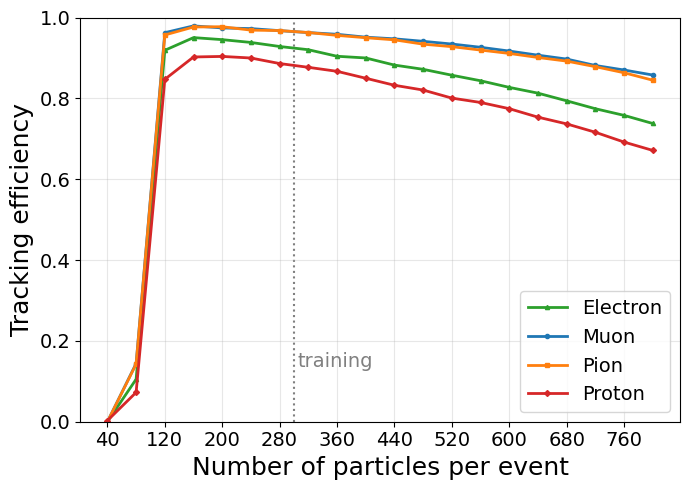

Segment GNN (GT segments)
Saved: /data/alice/bkuipers/out_of_distribution_experiment/ood_efficiency_data_segment_GNN_GT.pdf


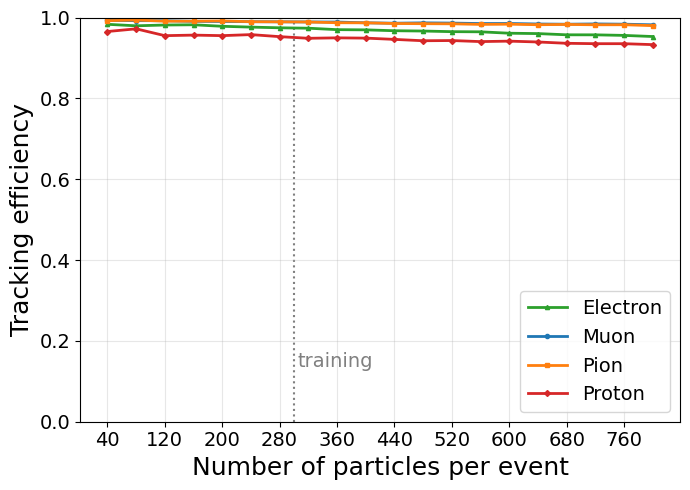

Helix matching (CC segments)
Saved: /data/alice/bkuipers/out_of_distribution_experiment/ood_efficiency_data_helix.pdf


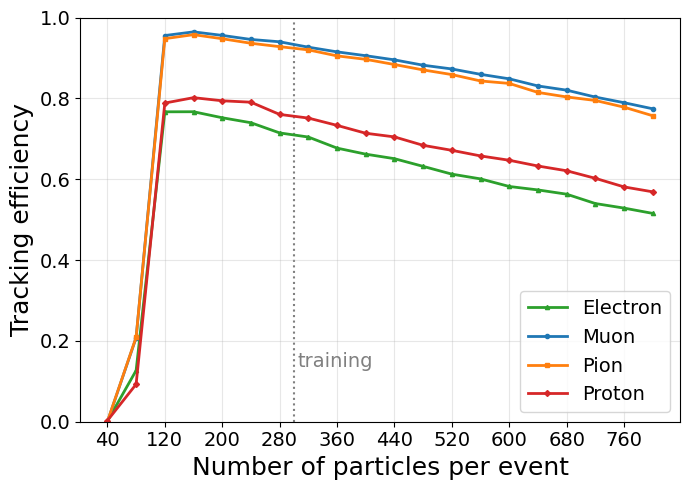

Helix matching (GT segments)
Saved: /data/alice/bkuipers/out_of_distribution_experiment/ood_efficiency_data_helix_GT.pdf


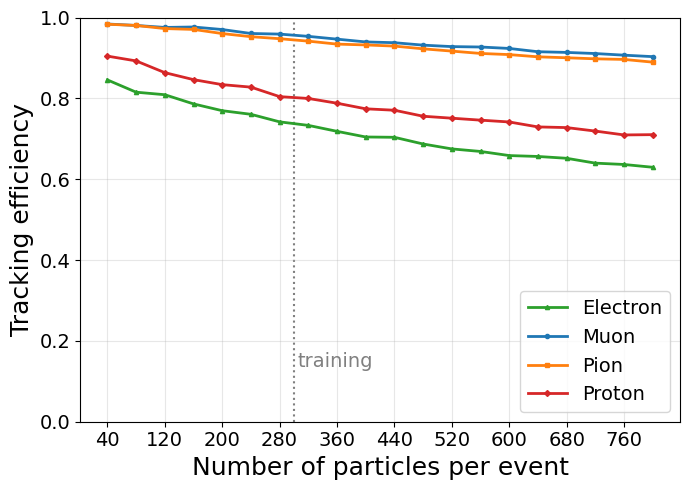

In [19]:
OOD_DIR = Path("/data/alice/bkuipers/out_of_distribution_experiment")

OOD_FILES = {
    "Segment GNN (CC segments)":    OOD_DIR / "ood_efficiency_data_segmentGNN.json",
    "Segment GNN (GT segments)":    OOD_DIR / "ood_efficiency_data_segment_GNN_GT.json",
    "Helix matching (CC segments)": OOD_DIR / "ood_efficiency_data_helix.json",
    "Helix matching (GT segments)": OOD_DIR / "ood_efficiency_data_helix_GT.json",
}

SPECIES_COLORS  = {"Muon": "#1f77b4", "Pion": "#ff7f0e", "Electron": "#2ca02c", "Proton": "#d62728"}
SPECIES_MARKERS = {"Muon": "o", "Pion": "s", "Electron": "^", "Proton": "D"}

for title, json_path in OOD_FILES.items():
    if not json_path.exists():
        print(f"Missing: {json_path}"); continue
    with open(json_path) as f:
        cache = json.load(f)

    print(title)
    fig, ax = plt.subplots(figsize=FIGSIZE)
    for name, d in sorted(cache["per_species"].items()):
        ax.plot(d["x"], [e / 100 for e in d["eff"]],
                marker=SPECIES_MARKERS.get(name, "o"),
                color=SPECIES_COLORS.get(name, "gray"),
                lw=2, markersize=MARKERSIZE, label=name)

    ax.axvline(300, color="gray", lw=1.5, linestyle=":", zorder=0)
    ax.text(305, 0.15, "training", ha="left", va="center", fontsize=FONT_LEGEND, color="gray")
    ax.set_xlabel("Number of particles per event", fontsize=FONT_AXIS)
    ax.set_ylabel("Tracking efficiency", fontsize=FONT_AXIS)
    ax.tick_params(labelsize=FONT_TICK)
    ax.set_xticks(cache["overall"]["x"][::2])
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=GRID_ALPHA)
    ax.legend(fontsize=FONT_LEGEND, loc="lower right")
    fig.tight_layout()

    out_path = json_path.with_suffix(".pdf")
    fig.savefig(out_path, bbox_inches="tight", dpi=DPI)
    print(f"Saved: {out_path}")
    plt.show()


### Combined: classical CKF vs GNN pipelines (overall efficiency vs multiplicity)

Single comparison of the classical CKF against the two GNN track builders. CKF efficiency is read from `performance_analysis/results/ckf_accuracy_all.json` (dataset `data_N` → `4N` particles/event, same matching cuts as the GNN evaluator: two-way, 0.7 fraction, target pT ≥ 0.1 GeV, ≥ 7 hits). The GNN curves use the `overall` efficiency from the OOD JSONs, which is the true matched/matchable summed over all particles — i.e. already weighted by species count, no manual averaging.

Saved: /data/alice/bkuipers/out_of_distribution_experiment/efficiency_vs_multiplicity_ckf_vs_gnn.pdf


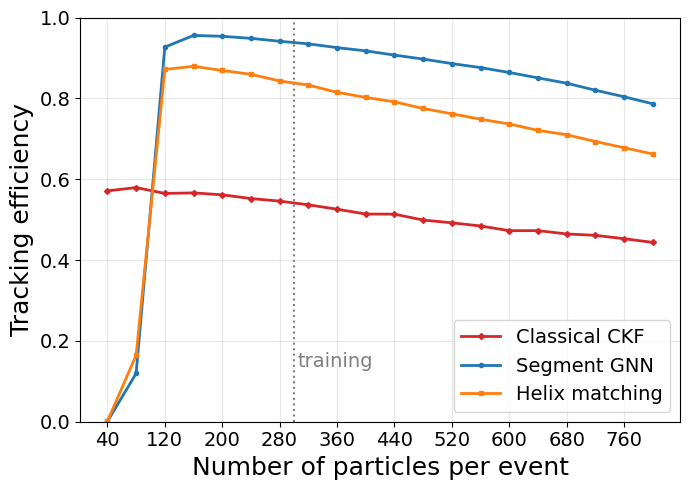

In [20]:
# ── Combined: classical CKF vs the two GNN pipelines (overall efficiency) ─────
# CKF eff vs multiplicity comes from performance_analysis/results/ckf_accuracy_all.json,
# datasets data_N -> 4*N particles/event (data_10..data_200 -> 40..800), confirmed
# against results_ckf.json. The GNN curves are the already-count-weighted "overall"
# efficiency from the OOD JSONs (true matched/matchable over all species), so no
# manual species averaging is needed. CC-segment (deployable) variants are used,
# the fair counterpart to the full classical CKF reco.
CKF_ACC = Path("/data/alice/bkuipers/low_pt_gnn_pipeline/performance_analysis/results/ckf_accuracy_all.json")

# CKF: dataset data_N -> multiplicity 4*N, efficiency stored as a fraction.
_ckf = json.load(open(CKF_ACC))["records"]
_ckf_pts = sorted(((int(r["dataset"].split("_")[1]) * 4, r["efficiency"]) for r in _ckf),
                  key=lambda t: t[0])
ckf_x   = [p for p, _ in _ckf_pts]
ckf_eff = [e for _, e in _ckf_pts]          # already 0..1

# GNN overall curves (stored in percent -> /100).
GNN_CURVES = [
    ("Segment GNN", OOD_DIR / "ood_efficiency_data_segmentGNN.json", "#1f77b4", "o"),
    ("Helix matching", OOD_DIR / "ood_efficiency_data_helix.json",   "#ff7f0e", "s"),
]

fig, ax = plt.subplots(figsize=FIGSIZE)
ax.plot(ckf_x, ckf_eff, marker="D", color="#d62728", lw=2, markersize=MARKERSIZE,
        label="Classical CKF")
for name, path, color, marker in GNN_CURVES:
    cache = json.load(open(path))
    ax.plot(cache["overall"]["x"], [e / 100 for e in cache["overall"]["eff"]],
            marker=marker, color=color, lw=2, markersize=MARKERSIZE, label=name)

ax.axvline(300, color="gray", lw=1.5, linestyle=":", zorder=0)
ax.text(305, 0.15, "training", ha="left", va="center", fontsize=FONT_LEGEND, color="gray")
ax.set_xlabel("Number of particles per event", fontsize=FONT_AXIS)
ax.set_ylabel("Tracking efficiency", fontsize=FONT_AXIS)
ax.tick_params(labelsize=FONT_TICK)
ax.set_xticks(ckf_x[::2])
ax.set_ylim(0, 1)
ax.grid(True, alpha=GRID_ALPHA)
ax.legend(fontsize=FONT_LEGEND, loc="lower right")
fig.tight_layout()

out_path = OOD_DIR / "efficiency_vs_multiplicity_ckf_vs_gnn.pdf"
fig.savefig(out_path, bbox_inches="tight", dpi=DPI)
print(f"Saved: {out_path}")
plt.show()


## Fake rate vs $p_T$ (computed from track_evaluation CSVs)

Read directly from the raw evaluation `matching_df_*.csv` so we don't need to re-run the GNN pipeline. The eval directory is derived from `PLOT_DIR` (replacing `visuals/track_metrics` with `track_evaluation`), so changing `PLOT_DIR` to a different testset automatically points the lookup at the matching CSV.

A **fake** is a proposed track matched to no GT particle. `matching_df` stores one row per (track, particle) *overlap*, so we first collapse to one entry per track (`track_id == -1` is the per-event noise bucket and is dropped). A track is fake iff *none* of its rows has `is_matched == True`.

Every track is binned by its **majority particle** (largest `n_shared`) → that particle's `(pt, species)`. The y-axis is the **fraction**

`fake rate(bin) = (# fake tracks in bin) / (# tracks in bin)`,

i.e. of all proposed tracks whose majority particle lands in a given pt bin, what fraction are fakes.


Reading: /data/alice/bkuipers/low_pt_gnn_pipeline/data_300_mixed/track_evaluation/testset_helix_minlen7/matching_df_testset_helix_minlen7.csv


/tmp/ipykernel_938843/2278191213.py:77: RuntimeWarning: invalid value encountered in divide
  p  = np.where(total > 0, passed / total, np.nan)


Saved: /data/alice/bkuipers/low_pt_gnn_pipeline/data_300_mixed/visuals/track_metrics/testset_helix_minlen7/fake_rate_vs_pt_testset_helix_minlen7.pdf


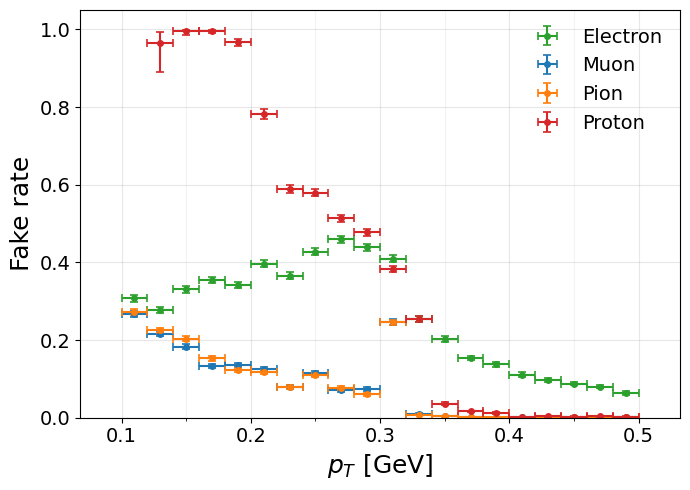

In [21]:
# Derive the track_evaluation directory from PLOT_DIR.

PLOT_DIR = Path("/data/alice/bkuipers/low_pt_gnn_pipeline/data_300_mixed/visuals/track_metrics/testset_helix_minlen7")
_EVAL_DIR = Path(str(PLOT_DIR).replace(
    "visuals/track_metrics", "track_evaluation"
))


_DATASET  = PLOT_DIR.name   # e.g. 'testset_SegmentGNN_GT'
_CSV_PATH = _EVAL_DIR / f"matching_df_{_DATASET}.csv"
print(f"Reading: {_CSV_PATH}")
assert _CSV_PATH.exists(), f"no matching_df at {_CSV_PATH}"

import csv
from collections import defaultdict

PT_EDGES   = np.linspace(0.10, 0.50, 21)         # 20 bins of 20 MeV
PT_CENTERS = 0.5 * (PT_EDGES[:-1] + PT_EDGES[1:])
PT_HALF    = 0.5 * (PT_EDGES[1] - PT_EDGES[0])

SPECIES_COLORS_FAKE = {
    "Electron": "#2ca02c", "Muon": "#1f77b4",
    "Pion": "#ff7f0e",     "Proton": "#d62728",
}

# ── Fake rate is a PER-TRACK fraction ────────────────────────────────────────
# A fake = a proposed track matched to no GT particle.
# matching_df has one row per (track, particle) overlap, so collapse to one
# entry per reconstructed track first:
#   * skip track_id == -1 (the per-event noise bucket, not a real track)
#   * a track is FAKE iff none of its rows has is_matched == True
# Bin every track by its MAJORITY particle (largest n_shared) -> that
# particle's (pt, species). Fake rate per bin = (# fake tracks) / (# tracks).
_tracks = defaultdict(list)   # (event_id, track_id) -> list of rows
with open(_CSV_PATH) as _f:
    for row in csv.DictReader(_f):
        if row["track_id"] == "-1":
            continue
        if row["is_matchable"].lower() not in ("true", "1"):
            continue   # match summary fake rate: only matchable tracks (>= min_track_length, fiducial)
        _tracks[(row["event_id"], row["track_id"])].append(row)

per_species = defaultdict(lambda: {
    "tot": np.zeros(len(PT_CENTERS), dtype=int),
    "fk":  np.zeros(len(PT_CENTERS), dtype=int),
})
all_tot = np.zeros(len(PT_CENTERS), dtype=int)
all_fk  = np.zeros(len(PT_CENTERS), dtype=int)

for _rows in _tracks.values():
    maj = max(_rows, key=lambda r: int(r["n_shared"]))   # majority particle
    try:
        pt = float(maj["pt"])
    except ValueError:
        continue
    if pt < PT_EDGES[0] or pt >= PT_EDGES[-1]:
        continue
    b = int(np.searchsorted(PT_EDGES, pt, side='right') - 1)
    is_fake = not any(r["is_matched"].lower() in ("true", "1") for r in _rows)
    sp = maj["particle_type"]
    per_species[sp]["tot"][b] += 1
    if is_fake: per_species[sp]["fk"][b] += 1
    all_tot[b] += 1
    if is_fake: all_fk[b] += 1

# Clopper-Pearson 68% interval — identical method/level to _clopper_pearson_errors
# in track_evaluation_utils.py, so the fake-rate bars match the efficiency/clone-rate
# plots. Asymmetric: a bin at 1.0 (all fake) gets a one-sided downward bar, and a
# bin at 0.0 a one-sided upward bar, instead of the misleading zero-length
# normal-approximation sqrt(p(1-p)/n) error.
from scipy.stats import beta as _beta
def _clopper_pearson(passed, total, level=0.68):
    passed = np.asarray(passed, float); total = np.asarray(total, float)
    a = (1 - level) / 2
    lo = np.where(passed > 0, _beta.ppf(a, passed, total - passed + 1), 0.0)
    hi = np.where(passed < total, _beta.ppf(1 - a, passed + 1, total - passed), 1.0)
    p  = np.where(total > 0, passed / total, np.nan)
    return np.maximum(0, p - lo), np.maximum(0, hi - p)

# Plot
fig, ax = plt.subplots(figsize=FIGSIZE)
for sp in ["Electron", "Muon", "Pion", "Proton"]:
    if sp not in per_species: continue
    tot = per_species[sp]["tot"].astype(float)
    fk  = per_species[sp]["fk"].astype(float)
    valid = tot > 0
    if not valid.any(): continue
    eff = np.where(valid, fk / np.where(valid, tot, 1), np.nan)
    lo_err, hi_err = _clopper_pearson(fk, tot)   # asymmetric 68% CI
    color = SPECIES_COLORS_FAKE.get(sp, "gray")
    ax.errorbar(PT_CENTERS[valid], eff[valid],
                xerr=PT_HALF, yerr=[lo_err[valid], hi_err[valid]],
                fmt="o", color=color, markersize=4,
                capsize=3, capthick=1.2, label=sp)

# (All species curve omitted; overall value still shown in the title)

ax.set_xlabel(r"$p_T$ [GeV]", fontsize=FONT_AXIS)
ax.set_ylabel("Fake rate", fontsize=FONT_AXIS)
ax.tick_params(axis="both", labelsize=FONT_TICK)
_title_overall = (all_fk.sum() / max(all_tot.sum(), 1))
# ax.set_title(f"Track fake rate vs $p_T$ ({_DATASET}, overall: {_title_overall:.3f})", fontsize=14)
_xpad = max((PT_EDGES[-1] - PT_EDGES[0]) * 0.08, 0.02)   # same padding as render_plot AUTO_XLIM
ax.set_xlim(PT_EDGES[0] - _xpad, PT_EDGES[-1] + _xpad)   # -> 0.1 major-tick labels, 0.05 gray minor grid
ax.set_ylim(0.0, 1.05)                                    # a touch of headroom; ticks still top out at 1.0
ax.set_yticks(np.arange(0.0, 1.01, 0.2))
ax.grid(True, alpha=0.3)
add_pt_minor_grid(ax)
ax.legend(fontsize=14, loc="upper right", frameon=False)
fig.tight_layout()
out = PLOT_DIR / f"fake_rate_vs_pt_{_DATASET}.pdf"
fig.savefig(out, bbox_inches="tight", dpi=150)
print(f"Saved: {out}")
plt.show()


Saved: /data/alice/bkuipers/low_pt_gnn_pipeline/data_300_mixed/visuals/track_metrics/testset_helix_minlen7/fake_completeness_testset_helix_minlen7.pdf


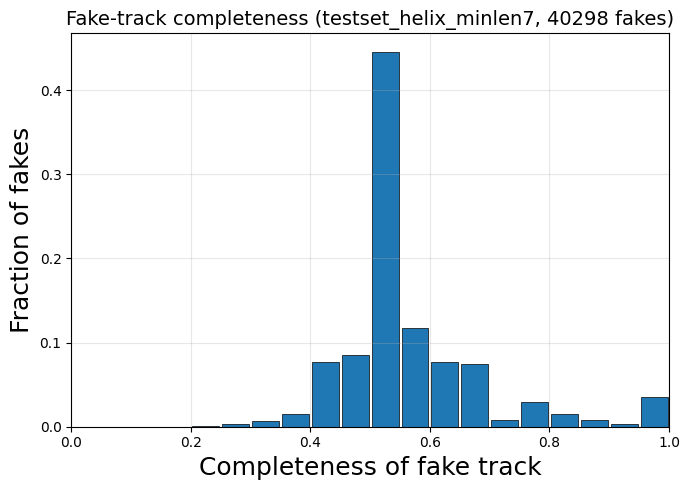

Saved: /data/alice/bkuipers/low_pt_gnn_pipeline/data_300_mixed/visuals/track_metrics/testset_helix_minlen7/fake_purity_testset_helix_minlen7.pdf


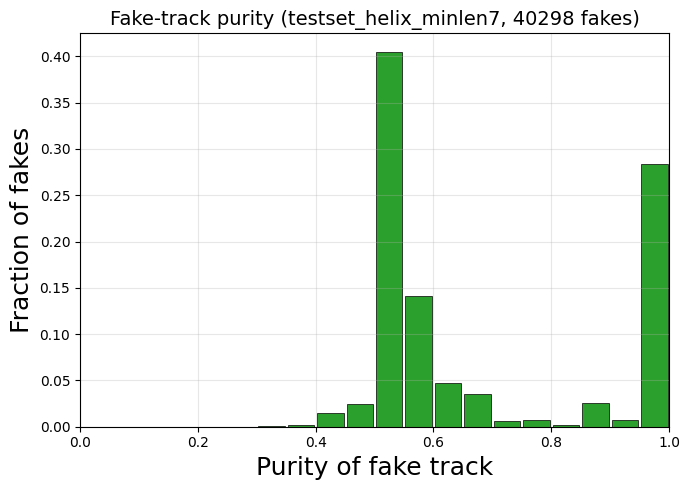

40298 fake tracks


In [22]:
# ── FAKE-track quality: completeness & purity distributions ──────────────────
# Same fake definition as the fake-rate cell above (run that first so _CSV_PATH,
# PLOT_DIR, _DATASET are defined): a fake = track (track_id != -1, is_matchable)
# with NO is_matched row. For each fake we take its MAJORITY particle (largest
# n_shared) and read that overlap's
#   completeness = eff_true     (n_shared / n_true_hits)
#   purity       = purity_reco  (n_shared / n_reco_hits)
# Each bar = fraction of ALL fake tracks landing in that bin (bars sum to 1).
_fk_tracks = defaultdict(list)
with open(_CSV_PATH) as _f:
    for row in csv.DictReader(_f):
        if row["track_id"] == "-1":
            continue
        if row["is_matchable"].lower() not in ("true", "1"):
            continue
        _fk_tracks[(row["event_id"], row["track_id"])].append(row)

_comp, _pur = [], []
for _rows in _fk_tracks.values():
    if any(r["is_matched"].lower() in ("true", "1") for r in _rows):
        continue                                    # matched -> not a fake
    maj = max(_rows, key=lambda r: int(r["n_shared"]))
    try:
        _comp.append(float(maj["eff_true"]))
        _pur.append(float(maj["purity_reco"]))
    except (ValueError, KeyError):
        continue
_comp = np.array(_comp); _pur = np.array(_pur)
_n_fake = len(_comp)

_Q_EDGES   = np.arange(0.0, 1.0001, 0.05)           # 20 bins of 0.05
_Q_CENTERS = 0.5 * (_Q_EDGES[:-1] + _Q_EDGES[1:])
_Q_BW      = _Q_EDGES[1] - _Q_EDGES[0]

for _data, _xlabel, _color, _tag in [
        (_comp, "Completeness", "#1f77b4", "completeness"),
        (_pur,  "Purity",       "#2ca02c", "purity")]:
    fig, ax = plt.subplots(figsize=FIGSIZE)
    _h, _ = np.histogram(_data, bins=_Q_EDGES)
    _frac = _h / max(_n_fake, 1)
    ax.bar(_Q_CENTERS, _frac, width=_Q_BW * 0.9,
           color=_color, edgecolor="black", linewidth=0.5)
    ax.set_xlabel(f"{_xlabel} of fake track", fontsize=FONT_AXIS)
    ax.set_ylabel("Fraction of fakes", fontsize=FONT_AXIS)
    ax.set_title(f"Fake-track {_xlabel.lower()} ({_DATASET}, {_n_fake} fakes)",
                 fontsize=14)
    ax.set_xlim(0.0, 1.0)
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    _out = PLOT_DIR / f"fake_{_tag}_{_DATASET}.pdf"
    fig.savefig(_out, bbox_inches="tight", dpi=150)
    print(f"Saved: {_out}")
    plt.show()

print(f"{_n_fake} fake tracks")


Saved: /data/alice/bkuipers/low_pt_gnn_pipeline/data_300_mixed/visuals/track_metrics/testset_helix_minlen7/fake_joint_comp_purity_testset_helix_minlen7.pdf


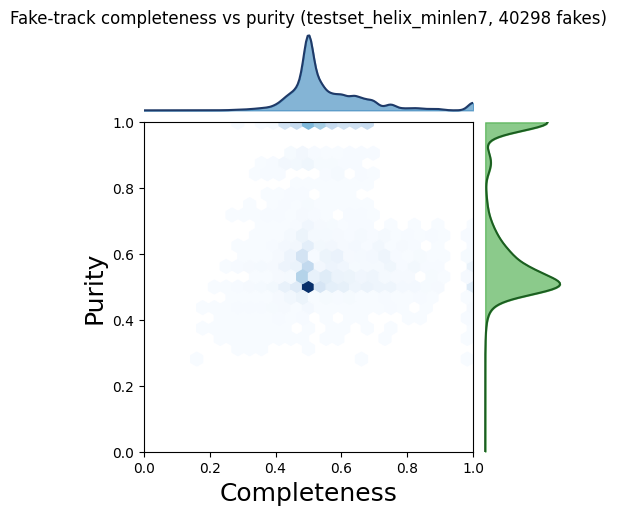

In [23]:
# ── Option A: 2D joint density (completeness vs purity) + marginal KDEs ───────
# Reuses _comp, _pur, _n_fake from the fake-quality cell above (run it first).
from scipy.stats import gaussian_kde
_xx = np.linspace(0, 1, 200)

fig = plt.figure(figsize=(FIGSIZE[1], FIGSIZE[1]))
gs = fig.add_gridspec(2, 2, width_ratios=(4, 1), height_ratios=(1, 4),
                      left=0.13, right=0.97, bottom=0.11, top=0.95,
                      wspace=0.04, hspace=0.04)
ax       = fig.add_subplot(gs[1, 0])
ax_top   = fig.add_subplot(gs[0, 0], sharex=ax)
ax_right = fig.add_subplot(gs[1, 1], sharey=ax)

ax.hexbin(_comp, _pur, gridsize=28, extent=(0, 1, 0, 1), cmap="Blues", mincnt=1)
ax.set_xlabel("Completeness", fontsize=FONT_AXIS)
ax.set_ylabel("Purity", fontsize=FONT_AXIS)
ax.set_xlim(0, 1); ax.set_ylim(0, 1)

_kc = gaussian_kde(_comp)(_xx)
ax_top.fill_between(_xx, _kc, color="#1f77b4", alpha=0.55)
ax_top.plot(_xx, _kc, color="#1f3a68", lw=1.5)
_kp = gaussian_kde(_pur)(_xx)
ax_right.fill_betweenx(_xx, _kp, color="#2ca02c", alpha=0.55)
ax_right.plot(_kp, _xx, color="#1b5e20", lw=1.5)
for _a in (ax_top, ax_right):
    _a.axis("off")
ax_top.set_title(f"Fake-track completeness vs purity ({_DATASET}, {_n_fake} fakes)",
                 fontsize=12)
_out = PLOT_DIR / f"fake_joint_comp_purity_{_DATASET}.pdf"
fig.savefig(_out, bbox_inches="tight", dpi=150)
print(f"Saved: {_out}")
plt.show()


Saved: /data/alice/bkuipers/low_pt_gnn_pipeline/data_300_mixed/visuals/track_metrics/testset_helix_minlen7/fake_joint_loghex_testset_helix_minlen7.pdf


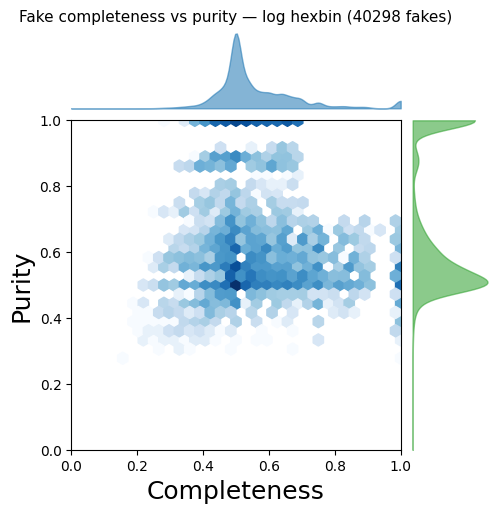

In [24]:
# ── Option A1: joint with LOG-scaled hexbin (reveals the faint mid-density) ───
# Same joint+marginal layout as A, but the hexbin colour is log-scaled so the
# central ridge is visible despite the dominant (0.5, 1.0) spike.
from scipy.stats import gaussian_kde
_xx = np.linspace(0, 1, 200)
fig = plt.figure(figsize=(FIGSIZE[1], FIGSIZE[1]))
gs = fig.add_gridspec(2, 2, width_ratios=(4, 1), height_ratios=(1, 4),
                      left=0.13, right=0.97, bottom=0.11, top=0.95,
                      wspace=0.04, hspace=0.04)
ax = fig.add_subplot(gs[1, 0]); ax_top = fig.add_subplot(gs[0, 0], sharex=ax)
ax_right = fig.add_subplot(gs[1, 1], sharey=ax)
ax.hexbin(_comp, _pur, gridsize=32, extent=(0, 1, 0, 1),
          cmap="Blues", mincnt=1, bins="log")
ax.set_xlabel("Completeness", fontsize=FONT_AXIS); ax.set_ylabel("Purity", fontsize=FONT_AXIS)
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax_top.fill_between(_xx, gaussian_kde(_comp)(_xx), color="#1f77b4", alpha=0.55)
ax_right.fill_betweenx(_xx, gaussian_kde(_pur)(_xx), color="#2ca02c", alpha=0.55)
ax_top.axis("off"); ax_right.axis("off")
ax_top.set_title(f"Fake completeness vs purity — log hexbin ({_n_fake} fakes)", fontsize=11)
_out = PLOT_DIR / f"fake_joint_loghex_{_DATASET}.pdf"
fig.savefig(_out, bbox_inches="tight", dpi=150); print(f"Saved: {_out}")
plt.show()


Saved: /data/alice/bkuipers/low_pt_gnn_pipeline/data_300_mixed/visuals/track_metrics/testset_helix_minlen7/fake_joint_annotated_testset_helix_minlen7.pdf


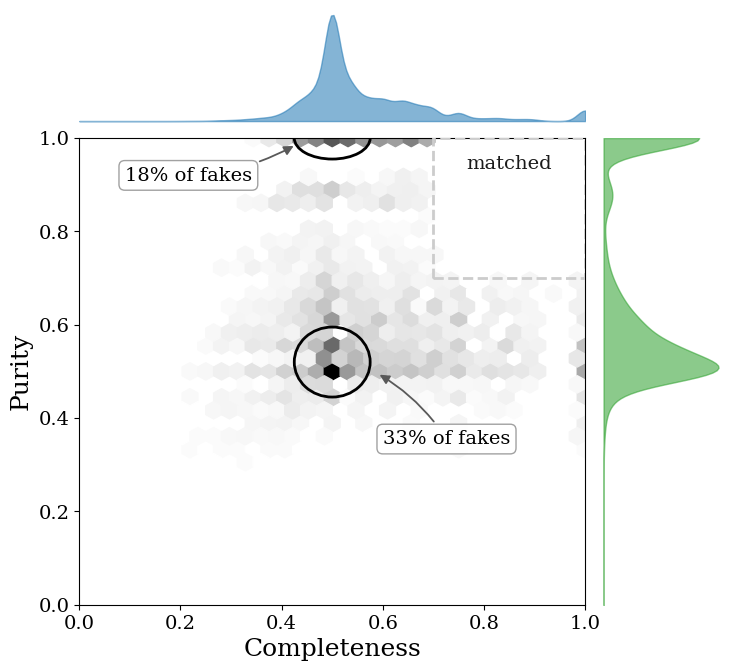

In [25]:
# ── Option A1-annotated: log hexbin + circled regions + % arrows ─────────────
# No on-figure description panel: the region explanations live in the LaTeX
# \caption{}. Each ring carries its number and a leader arrow to the fraction of
# all fakes inside it (computed live from _comp/_pur).
#   (cx, cy)=ellipse centre; (w, h)=axes; (tx, ty)=anchor of the % box (data).
from scipy.stats import gaussian_kde
from matplotlib.patches import Ellipse, Rectangle
from matplotlib.colors import PowerNorm

_REGIONS = [
    ("1", 0.50, 1, 0.15, 0.09, 0.09, 0.92, 0.00, 0.00),
    ("2", 0.50, 0.52, 0.15, 0.15, 0.60, 0.355, 0.05, 0.04),  # last two: arrow-head nudge (x, y)
    # ("3", 0.95, 0.50, 0.20, 0.40, 0.62, 0.20, 0.00, 0.00),
]

def _ellipse_frac(cx, cy, w, h):
    """Fraction of all fakes whose (completeness, purity) lies inside the ellipse."""
    m = ((_comp - cx) / (w / 2))**2 + ((_pur - cy) / (h / 2))**2 <= 1.0
    return m.sum() / max(len(_comp), 1)

_RC = {"font.family": "serif", "mathtext.fontset": "cm", "mathtext.rm": "serif"}

with plt.rc_context(_RC):
    _xx = np.linspace(0, 1, 200)
    fig = plt.figure(figsize=(7.5, 7))
    gs = fig.add_gridspec(2, 2, width_ratios=(4, 1), height_ratios=(1, 4),
                          left=0.11, right=0.97, bottom=0.10, top=0.95,
                          wspace=0.04, hspace=0.04)
    ax       = fig.add_subplot(gs[1, 0])
    ax_top   = fig.add_subplot(gs[0, 0], sharex=ax)
    ax_right = fig.add_subplot(gs[1, 1], sharey=ax)

    ax.hexbin(_comp, _pur, gridsize=32, extent=(0, 1, 0, 1),
              cmap="Greys", mincnt=1, norm=PowerNorm(gamma=0.4))
    ax.set_xlabel("Completeness", fontsize=FONT_AXIS); ax.set_ylabel("Purity", fontsize=FONT_AXIS)
    ax.tick_params(axis="both", labelsize=FONT_TICK)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax_top.fill_between(_xx, gaussian_kde(_comp)(_xx), color="#1f77b4", alpha=0.55); ax_top.axis("off")
    ax_right.fill_betweenx(_xx, gaussian_kde(_pur)(_xx), color="#2ca02c", alpha=0.55); ax_right.axis("off")

    # "Matched" region: two-way matching needs purity >= 0.7 AND completeness >= 0.7.
    ax.add_patch(Rectangle((0.7, 0.7), 0.3, 0.3, fill=False,
                           edgecolor="0.8", lw=2.0, linestyle="--", zorder=5))
    ax.text(0.85, 0.965, "matched", ha="center", va="top",
            fontsize=FONT_LEGEND, color="0.1", zorder=6)

    for _tag, _cx, _cy, _w, _h, _tx, _ty, _tnx, _tny in _REGIONS:
        ax.add_patch(Ellipse((_cx, _cy), _w, _h, fill=False, edgecolor="black", lw=2.0, zorder=5))
        _pct = 100 * _ellipse_frac(_cx, _cy, _w, _h)
        # arrow head lands on the ellipse boundary facing the text box
        _dx, _dy = _tx - _cx, _ty - _cy
        _t = 1.0 / np.hypot(_dx / (_w / 2), _dy / (_h / 2))
        _ex, _ey = _cx + _dx * _t + _tnx, _cy + _dy * _t + _tny
        ax.annotate(f"{_pct:.0f}% of fakes", xy=(_ex, _ey), xytext=(_tx, _ty), textcoords="data",
                    ha="left", va="center", fontsize=FONT_LEGEND, zorder=7,
                    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="0.6", alpha=0.92),
                    arrowprops=dict(arrowstyle="-|>", color="0.35", lw=1.3,
                                    connectionstyle="arc3,rad=0.12"))

    _out = PLOT_DIR / f"fake_joint_annotated_{_DATASET}.pdf"
    fig.savefig(_out, bbox_inches="tight", dpi=150); print(f"Saved: {_out}")
    plt.show()
